# AI for Synovium – Iteration 7  (GNN with Superpixels)
SLIC tiles (20 μm), 118 cases, radius graph, 5 hops, 3 samples, 64-dimensional features

### Generate SLIC superpixels in QuPath and export label information within each superpixel
Run scripts 01–03 in the qupath/scripts directory sequentially within QuPath.

In [1]:
import os
import numpy as np
import pandas as pd
import tqdm as tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import NeighborSampler as RawNeighborSampler
from torch_geometric.nn import SAGEConv
from torch_cluster import random_walk

from sklearn.neighbors import radius_neighbors_graph

import networkx as nx
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
import seaborn as sns
import matplotlib.colors as mcolors
from glob import glob
import h5py

## HDF5

In [ ]:
paths = glob("data/labelRatio_241117/*.txt")
len(paths)

In [ ]:
with h5py.File("data/GNN_InOut.h5", mode="w") as f:
    for path in tqdm.tqdm(paths):
        samplename = path.split("\\")[-1]
        samplename = samplename.split("_HE")[0]
        f.create_group(samplename)

In [ ]:
className = ["Background","Immune cells", "plasma", "Fibro(loose)", "Fibro(dense,regular)",
"Fibro(dense,irregular)", "lining", "vessel", "vessel(large)",
"adipose", "Stroma", "muscle", "RBC"]

with h5py.File("data/GNN_InOut.h5", mode="a") as f:
    for path in tqdm.tqdm(paths):
        samplename = path.split("\\")[-1]
        samplename = samplename.split("_HE")[0]

        df = pd.read_csv(path,index_col=0,sep="\t")

        f[samplename].create_dataset("index", data=df.index.to_numpy())
        points = df[["x","y"]].to_numpy()

        f[samplename].create_dataset("coord", data = points, compression = "gzip")

        df.drop(columns=["x","y"], inplace=True)

        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        row_sums = df.sum(axis=1)
        df_ratio = df.div(row_sums, axis=0)
        x = df_ratio.to_numpy()
        f[samplename].create_dataset("input_feat", data = x, compression = "gzip")

        idmax = df_ratio.idxmax(axis=1)
        idmax = [ int(i) for i in list(idmax)]
        labelmax = np.array(className)[idmax]

        f[samplename].create_dataset("tile_maxID", data = idmax, compression = "gzip")
        f[samplename].create_dataset("tile_maxLabel", data = np.array(labelmax, dtype='S'), compression = "gzip")

In [ ]:
with h5py.File("data/GNN_InOut.h5", mode="r") as f:
    groups = list(f.keys())

## Construct radius graph
Tiles are generated with a side length of 20 μm, so the distance between adjacent tile centers is -20 μm.
Diagonal neighbors are at 20 * sqrt(2) ≈ 30 μm, so a threshold of 30 μm should capture them.
Since coordinates are in pixels (~1.1 μm/px), we use a threshold of 35.
20 * sqrt(2) * 1.1023 = 31.17775

In [ ]:
radius = 35

with h5py.File("data/GNN_InOut.h5", mode="a") as f:
    for donor in tqdm.tqdm(groups):
        points = f[donor]["coord"]
        adj_matrix = radius_neighbors_graph(X=points, radius=radius)
        edge_index = np.argwhere(adj_matrix > 0)
        f[donor].create_dataset("edge_index", data=edge_index, compression="gzip")

## Create batch dataset

In [ ]:
data_list = []

with h5py.File("data/GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        edge_index = f[donor]["edge_index"]
        features = f[donor]["input_feat"]

        x = torch.from_numpy(features[:]).to(torch.float32)
        edge_index = torch.from_numpy(edge_index[:]).to(torch.long)

        data = Data(x=x, edge_index=edge_index.t().contiguous(), donor=donor)
        data_list.append(data)

In [3]:
dataset = torch_geometric.data.Batch.from_data_list(data_list)

In [4]:
dataset

DataBatch(x=[12100353, 12], edge_index=[2, 94575914], donor=[118], batch=[12100353], ptr=[119])

## Prepare components required for GNN (mixed precision version)

In [ ]:
from torch_geometric.data import NeighborSampler as RawNeighborSampler
from torch_cluster import random_walk

class NeighborSampler(RawNeighborSampler):
    """
    Custom NeighborSampler overriding the sample function of PyG's NeighborSampler.
    All methods except sample are inherited from the parent class.
    Input:
        Node indices corresponding to the batch
    Process:
        1. Sample one neighboring node from connected nodes (random walk) → positive samples
        2. Randomly sample nodes from the entire graph → negative samples
        3. Pass batch nodes, positive samples, and negative samples to the parent sample function
           to retrieve their connectivity information
    """

    def sample(self, batch):
        batch = torch.tensor(batch)    
        row,col,_ = self.adj_t.coo()

        pos_batch = random_walk(
            row=row,
            col=col,
            start=batch,
            walk_length=1,
            coalesced=False
        )
        
        pos_batch = pos_batch[:,1] 

        neg_batch = torch.randint(
            low=0,
            high=self.adj_t.size(1), 
            size=(batch.numel(), ), 
            dtype=torch.long)

        batch = torch.cat([batch, pos_batch, neg_batch], dim=0)

        batch = super(NeighborSampler, self).sample(batch)    
        
        return batch

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class SAGE(torch.nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 output_channels,
                 num_layers
                ):
        
        super(SAGE, self).__init__()
        self.num_layers = num_layers

        self.convs = nn.ModuleList()
        for i in range(num_layers):
            in_channels = in_channels if i==0 else hidden_channels
            out_channels = hidden_channels if i < num_layers-1 else output_channels
            
            norm = True if i < num_layers-1 else False

            self.convs.append(SAGEConv(
                in_channels, out_channels, 
                normalize=norm, 
                root_weight=True))
            
    def forward(self, x, adjs):
        for i, (edge_index, _, size) in enumerate(adjs):
            x_target = x[:size[1]]

            x = self.convs[i]((x, x_target), edge_index)
            
            if i != self.num_layers-1:
                x = x.relu()
                x = F.dropout(x, p=0.25, training=self.training)
        return x

    def full_forward(self, x, edge_index):
        for i,conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != self.num_layers - 1:
                x = x.relu()
                x = F.dropout(x, p=0.25, training=self.training)
        return x

In [ ]:
def train(model, x, optimizer, train_loader, device="cuda", use_amp=True):

    num_nodes = x.shape[0]
    model.train()
    model = model.to(device)
    x = x.to(device)
    total_loss = 0

    scaler = torch.amp.GradScaler(enabled=use_amp)

    pbar = tqdm.tqdm(train_loader)
    for batch_size, n_id, adjs in pbar:
        adjs = [adj.to(device) for adj in adjs]

        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            out = model(x[n_id], adjs)

            out, pos_out, neg_out = out.split(out.size(0) // 3, dim=0)

            pos_loss = F.logsigmoid((out * pos_out).sum(-1)).mean()
            neg_loss = F.logsigmoid(-(out * neg_out).sum(-1)).mean()
            loss = -pos_loss - neg_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss) * out.size(0)
        pbar.set_description(
                f"loss: {loss:.4f}, pos_loss: {pos_loss:.4f}, neg_loss: {neg_loss:.4f}"
        )

    return total_loss / num_nodes

## Training (batch size: 8192)

In [ ]:
sampling = 3
num_layers = 5
batch_size =8192
device = "cuda"labelRatio

train_loader = NeighborSampler(
    dataset.edge_index,
    sizes=[3]*num_layers, 
    batch_size=batch_size,
    shuffle=True,
    num_nodes=dataset.num_nodes,
    drop_last=True
)

model = SAGE(
    in_channels=dataset.num_node_features,
    hidden_channels=256,
    output_channels=64,
    num_layers=num_layers)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### Training

In [ ]:
save_dir = "data/model_checkpoint_241118"
os.makedirs(save_dir,exist_ok=True)

best_loss = 1
save_path = f"{save_dir}/best_checkpoint.pt"

history = []

for i in range(40):
    loss = train(model, dataset.x, optimizer, train_loader,device)
    print(loss)
    history.append(loss)
    if loss < best_loss:
        torch.save(model.state_dict(), save_path)
        best_loss = loss

loss: 0.8610, pos_loss: -0.0698, neg_loss: -0.7911: 100%|██████████| 1477/1477 [3:20:46<00:00,  8.16s/it]  


0.9117192002709549


loss: 0.8360, pos_loss: -0.0668, neg_loss: -0.7692: 100%|██████████| 1477/1477 [3:41:45<00:00,  9.01s/it]  


0.8494135867100323


loss: 0.8388, pos_loss: -0.0592, neg_loss: -0.7796: 100%|██████████| 1477/1477 [3:35:20<00:00,  8.75s/it]  


...

0.7688565433632133


loss: 0.7689, pos_loss: -0.0285, neg_loss: -0.7404: 100%|██████████| 1477/1477 [3:40:25<00:00,  8.95s/it]  


0.7686928464423595


loss: 0.7662, pos_loss: -0.0285, neg_loss: -0.7377: 100%|██████████| 1477/1477 [3:38:27<00:00,  8.87s/it]  

0.7686910034563532


#### -> Training started at -10.8 GB GPU memory usage, later increased to -18 GB


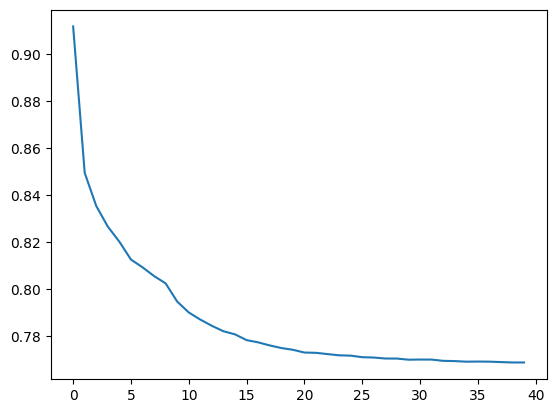

In [10]:
plt.plot(history)

## Save model

In [ ]:
torch.save(model,"model_weights/CancerCell_model_20um_5hop3sample64feat_241118.pt")

## Prediction using trained model

In [12]:
model = model.to("cpu")
torch.cuda.empty_cache()

In [ ]:
with h5py.File("data/GNN_InOut.h5", mode="a") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        edge_index = f[donor]["edge_index"]
        features = f[donor]["input_feat"]

        x = torch.from_numpy(features[:]).to(torch.float32)
        edge_index = torch.from_numpy(edge_index[:]).to(torch.long)

        data = Data(x=x, edge_index=edge_index.t().contiguous(), donor=donor)
        pred_features = model.full_forward(
            data.x.cpu(),
            data.edge_index.cpu()
            ).detach().numpy()
        f[donor].create_dataset("pred_features", data=pred_features, compression = "gzip")

## Export features for QuPath

In [ ]:
with h5py.File("data/GNN_InOut.h5", mode="r") as f:
    def print_hdf5_structure(name, obj):
        print(name, obj)

    f.visititems(print_hdf5_structure)

D001 <HDF5 group "/D001" (7 members)>
D001/coord <HDF5 dataset "coord": shape (125418, 2), type "<f8">
D001/edge_index <HDF5 dataset "edge_index": shape (954766, 2), type "<i4">
D001/index <HDF5 dataset "index": shape (125418,), type "|O">
D001/input_feat <HDF5 dataset "input_feat": shape (125418, 12), type "<f8">
D001/pred_features <HDF5 dataset "pred_features": shape (125418, 64), type "<f4">
D001/tile_maxID <HDF5 dataset "tile_maxID": shape (125418,), type "<i8">
D001/tile_maxLabel <HDF5 dataset "tile_maxLabel": shape (125418,), type "|S22">
D002 <HDF5 group "/D002" (7 members)>
D002/coord <HDF5 dataset "coord": shape (37440, 2), type "<f8">
D002/edge_index <HDF5 dataset "edge_index": shape (622792, 2), type "<i4">
D002/index <HDF5 dataset "index": shape (37440,), type "|O">
D002/input_feat <HDF5 dataset "input_feat": shape (37440, 12), type "<f8">
D002/pred_features <HDF5 dataset "pred_features": shape (37440, 64), type "<f4">
D002/tile_maxID <HDF5 dataset "tile_maxID": shape (3744

In [ ]:
save_dir = "data/SLICTile_Features_241125"
os.makedirs(save_dir, exist_ok=True)

with h5py.File("data/GNN_InOut.h5", mode="r") as f:
    donors = list(f.keys())
    for donor in tqdm.tqdm(donors):
        features = f[donor]["pred_features"][:]
        index = f[donor]["index"][:].astype(str)

        write_df = pd.DataFrame(features,index=index)
        write_df.to_csv(f"{save_dir}/{donor}.txt",sep="\t",index_label="ID")
